# Curvas de Andrews y Firmas Topologicas
## Proyecto 5B: Interpretabilidad Topologica

**Integrantes:** Paula Guerrero, Pamela Mendoza, Tomas Ubilla

**Dataset:** Wine Quality (red wine), UCI Repository
- 1599 muestras, 11 atributos fisicoquimicos + calidad (3-8)

---


In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

df = pd.read_csv('../data/winequality-red.csv', sep=';')
X = df.drop(columns=['quality'])
y = df['quality']

print(f'Dataset: {df.shape[0]} muestras, {df.shape[1]-1} atributos')
print(f'Calidades: {sorted(y.unique())}')
print(f'Atributos: {list(X.columns)}')

Dataset: 1599 muestras, 11 atributos
Calidades: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Atributos: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


---
## 1. Que son las Curvas de Andrews?

Las Curvas de Andrews transforman cada observacion multivariada en una funcion periodica. Dado un vector de atributos $x = (x_1, ..., x_p)$, la curva es:

$f_x(t) = \frac{x_1}{\sqrt{2}} + x_2 \sin(t) + x_3 \cos(t) + x_4 \sin(2t) + x_5 \cos(2t) + \cdots$

Cada atributo se asigna a un termino trigonometrico de distinta frecuencia. Esto permite visualizar datos de alta dimension en 2D y ademas extraer caracteristicas topologicas mediante homologia persistente.

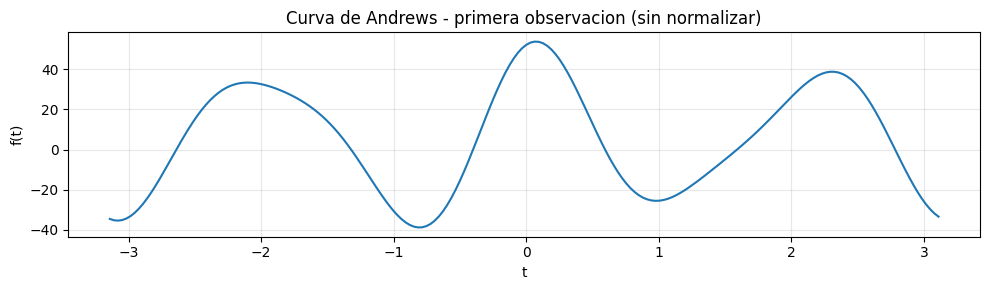

In [2]:
from src.andrews import encode, andrews_curve, normalize_data
from src.sublevel_persistence import persistence_diagram, persistence_statistics, h1_global_interval, build_periodic_complex

# Ejemplo: curva de Andrews de la primera observacion
t = np.linspace(-np.pi, np.pi, 200, endpoint=False)
row = X.iloc[0].values
curve = andrews_curve(row, t)

plt.figure(figsize=(10, 3))
plt.plot(t, curve)
plt.title('Curva de Andrews - primera observacion (sin normalizar)')
plt.xlabel('t'); plt.ylabel('f(t)'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 2. Efecto de la Normalizacion

Los atributos tienen escalas muy distintas (alcohol ~9-15, densidad ~0.99-1.00). Si no normalizamos, los atributos con valores grandes dominan la curva. Comparamos cuatro metodos:
- **None:** sin normalizar
- **Min-Max:** cada atributo entre 0 y 1
- **Z-score:** media 0, desviacion 1
- **Robust:** mediana 0, IQR 1 (resistente a outliers)

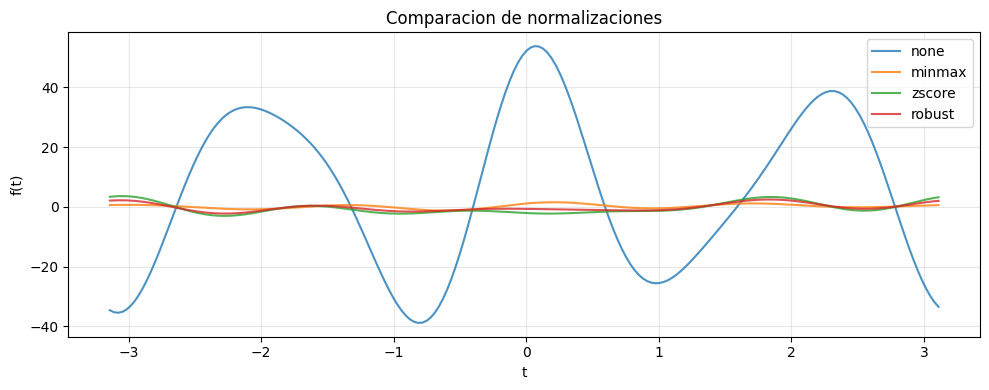

In [3]:
sample = X
curves_none, t = encode(sample, normalize='none', return_t=True)
curves_minmax = encode(sample, normalize='minmax')
curves_zscore = encode(sample, normalize='zscore')
curves_robust = encode(sample, normalize='robust')

plt.figure(figsize=(10, 4))
plt.plot(t, curves_none[0], label='none', alpha=0.8)
plt.plot(t, curves_minmax[0], label='minmax', alpha=0.8)
plt.plot(t, curves_zscore[0], label='zscore', alpha=0.8)
plt.plot(t, curves_robust[0], label='robust', alpha=0.8)
plt.title('Comparacion de normalizaciones')
plt.xlabel('t'); plt.ylabel('f(t)'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Resultado:** Sin normalizar, la amplitud es ~140 (dominada por densidad y sulfur dioxide). Min-Max, Z-score y Robust producen curvas con amplitudes comparables (~6-7). Z-score es la opcion mas usada en TDA y la que usaremos en adelante.

---
## 3. Efecto del Orden de Variables (visual)

Cada atributo se asigna a un termino trigonometrico segun su posicion. Al cambiar el orden, un atributo pasa a una frecuencia distinta, alterando la forma de la curva.

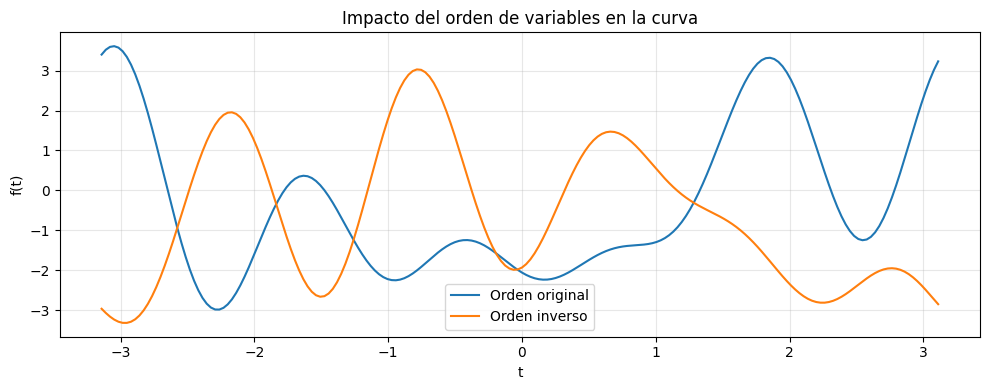

In [4]:
sample = X
original_order = list(range(X.shape[1]))
reverse_order = original_order[::-1]

curves_orig, t = encode(sample, normalize='zscore', order=original_order, return_t=True)
curves_rev = encode(sample, normalize='zscore', order=reverse_order)

plt.figure(figsize=(10, 4))
plt.plot(t, curves_orig[0], label='Orden original')
plt.plot(t, curves_rev[0], label='Orden inverso')
plt.title('Impacto del orden de variables en la curva')
plt.xlabel('t'); plt.ylabel('f(t)'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Se observa que la misma observacion produce curvas distintas al invertir el orden. Esto es relevante porque la topologia de la curva (pares peak/valle) depende del orden. Mas adelante cuantificaremos este efecto sobre los estadisticos topologicos.

---
## 4. Efecto de la Resolucion (N)

La curva se discretiza en N puntos en $[-\pi, \pi]$. Una resolucion baja puede perder detalles finos (picos angostos); una muy alta aumenta el costo computacional sin ganancia significativa.

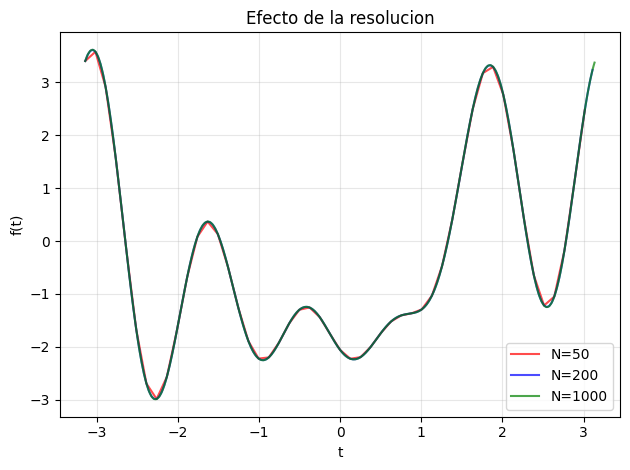

In [5]:
for N, color in [(50, 'red'), (200, 'blue'), (1000, 'green')]:
    curve, t = encode(sample, N=N, normalize='zscore', return_t=True)
    plt.plot(t, curve[0], label=f'N={N}', color=color, alpha=0.7)
plt.title('Efecto de la resolucion')
plt.xlabel('t'); plt.ylabel('f(t)'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

N=50 captura la forma general pero suaviza algunos picos. N=200 y N=1000 son casi identicos. Usaremos N=200 como equilibrio entre precision y eficiencia.

---
## 5. Curvas de Andrews por Clase de Calidad

Visualizamos curvas de observaciones representativas de cada calidad (3 a 8). Buscamos separacion visual entre clases.

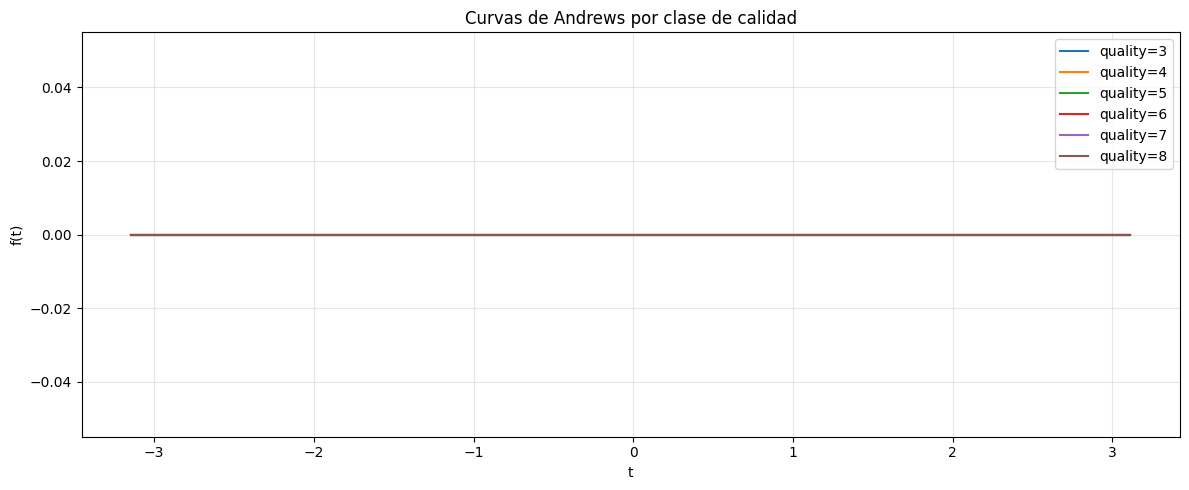

In [6]:
qualities = [3, 4, 5, 6, 7, 8]
plt.figure(figsize=(12, 5))
for q in qualities:
    idx = y[y == q].index[0]
    curve, t = encode(X.loc[[idx]], normalize='zscore', return_t=True)
    plt.plot(t, curve[0], label=f'quality={q}')
plt.title('Curvas de Andrews por clase de calidad')
plt.xlabel('t'); plt.ylabel('f(t)'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Las curvas se superponen entre clases. No hay separacion visual clara, lo que motiva usar TDA para capturar estructura mas fina no visible directamente.

---
## 6. Complejo Cubical 1D Periodico y Persistencia

Construimos un complejo simplicial sobre $S^1$: los N puntos de la curva son vertices, conectamos consecutivos (incluyendo el ultimo con el primero). Asignamos como filtracion el valor de la funcion en cada vertice (lower-star filtration).

Luego calculamos homologia persistente:
- **H0:** captura pares peak/valle locales de la curva.
- **H1:** captura el ciclo global (la curva en si). Su persistencia es max(f) - min(f).

In [7]:
curve = encode(X, normalize='zscore')[0]
h0, h1_gudhi, h1_global = persistence_diagram(curve)

print('H0 - intervalos persistentes:')
print(h0)
print(f'\nH1 (global): birth={h1_global[0][0]:.4f}, death={h1_global[0][1]:.4f}')
print(f'Lifetime H1 = {h1_global[0][1] - h1_global[0][0]:.4f}')

stats = persistence_statistics(h0)
print(f'\nEstadisticos H0:')
for k, v in stats.items():
    print(f'  {k}: {v}')

H0 - intervalos persistentes:
[[-2.23664252 -1.24495382]
 [-2.25227932  0.36670141]
 [-1.24866218  3.32244309]
 [-2.98621362         inf]]

H1 (global): birth=-2.9862, death=3.6132
Lifetime H1 = 6.5994

Estadisticos H0:
  num_pairs: 3
  total_persistence: 8.181774691163909
  max_life: 4.571105269401743
  entropy: 0.94565633700134


---
## 7. Analisis de Sensibilidad de Atributos

Estudiamos como varia la firma topologica (H0 y H1) al modificar cada atributo dentro de su rango, manteniendo los demas fijos. Normalizamos con z-score para que todas las variables sean comparables.

**Metricas que analizamos:**
- `num_pairs`: cantidad de pares peak/valle persistentes en H0
- `total_persistence`: suma de las vidas de esos pares (riqueza topologica)
- `entropy`: distribucion de las vidas (estructura multi-escala)
- `h1_lifetime`: amplitud global de la curva = max - min

In [8]:
def sensitivity_analysis(attr, n_steps=8):
    sample = X.iloc[0].copy()
    values = np.linspace(X[attr].min(), X[attr].max(), n_steps)
    records, h1_records, curves = [], [], {}
    for v in values:
        mod = sample.copy(); mod[attr] = v
        Xt = pd.concat([X, pd.DataFrame([mod])], ignore_index=True)
        Xn = normalize_data(Xt, method='zscore')
        mn = Xn[-1].reshape(1, -1)
        curve = encode(mn, normalize='none')
        curves[round(v, 4)] = curve[0]
        h0, _, h1g = persistence_diagram(curve[0])
        s = persistence_statistics(h0); s[attr] = v; records.append(s)
        hi = h1_global_interval(curve[0]); hi[attr] = v; h1_records.append(hi)
    return curves, pd.DataFrame(records), pd.DataFrame(h1_records)

def plot_sens(cv, st, h1, attr):
    tv = np.linspace(-np.pi, np.pi, len(list(cv.values())[0]), endpoint=False)
    plt.figure(figsize=(12, 2.5))
    for v, c in cv.items():
        plt.plot(tv, c, label=f'{v:.3f}')
    plt.title(f'Curvas al variar {attr}', fontsize=10)
    plt.xlabel('t'); plt.legend(fontsize=6); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(1, 4, figsize=(14, 3))
    for a, (m, t) in zip(ax[:3], [('num_pairs','Pares H0'),('total_persistence','Persistencia H0'),('entropy','Entropia H0')]):
        a.plot(st[attr], st[m], marker='o'); a.set_xlabel(attr); a.set_title(t); a.grid(True, alpha=0.3)
    ax[3].plot(h1[attr], h1['lifetime'], marker='o', color='green')
    ax[3].set_xlabel(attr); ax[3].set_title('Lifetime H1'); ax[3].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

### 7.1. Alcohol

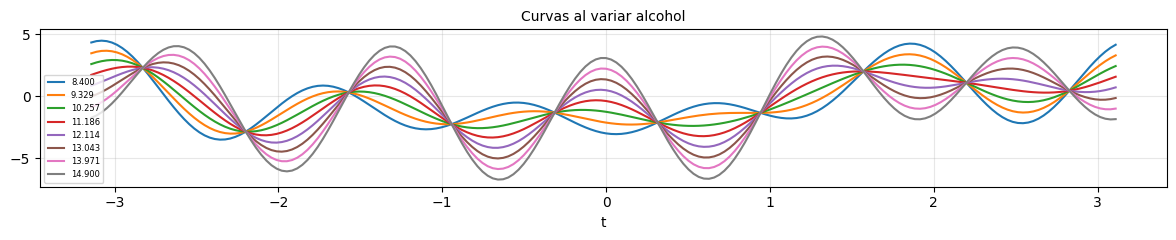

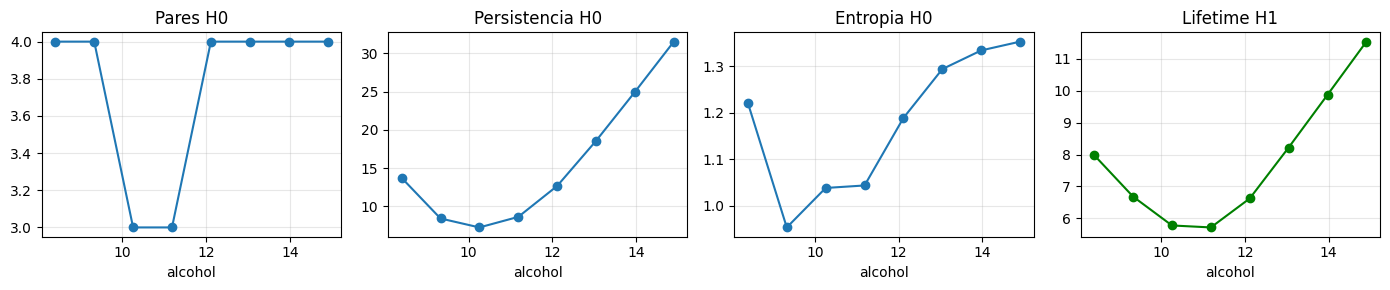

In [9]:
c, s, h = sensitivity_analysis('alcohol', n_steps=8)
plot_sens(c, s, h, 'alcohol')

El alcohol tiene el mayor impacto. Al aumentar, la persistencia total H0 crece fuertemente y el lifetime H1 tambien. Vinos con mayor alcohol tienen curvas con mas estructura topologica.

### 7.2. Citric Acid

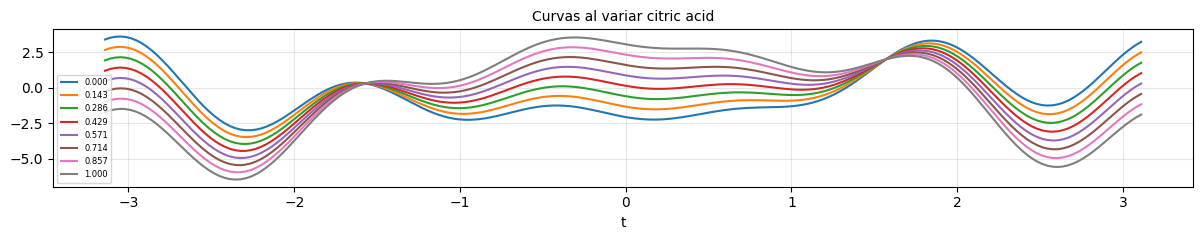

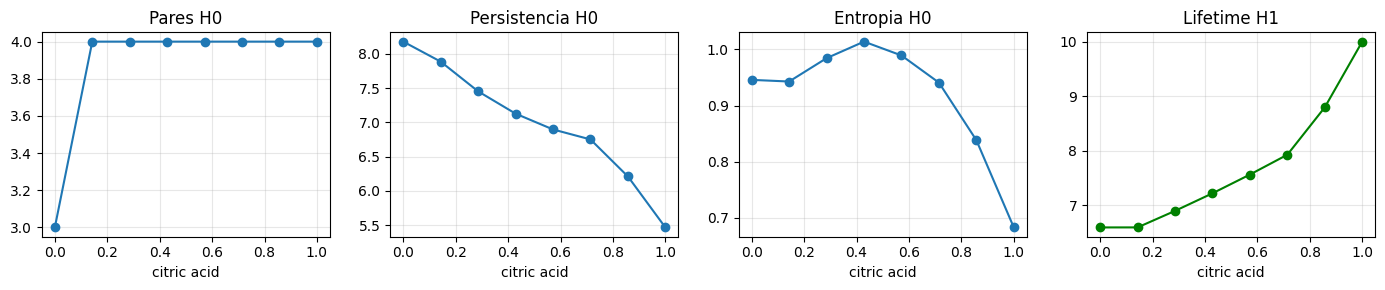

In [10]:
c, s, h = sensitivity_analysis('citric acid', n_steps=8)
plot_sens(c, s, h, 'citric acid')

El acido citrico tiene efecto minimo. Las 4 metricas se mantienen practicamente constantes. Es uno de los atributos menos influyentes.

### 7.3. Residual Sugar

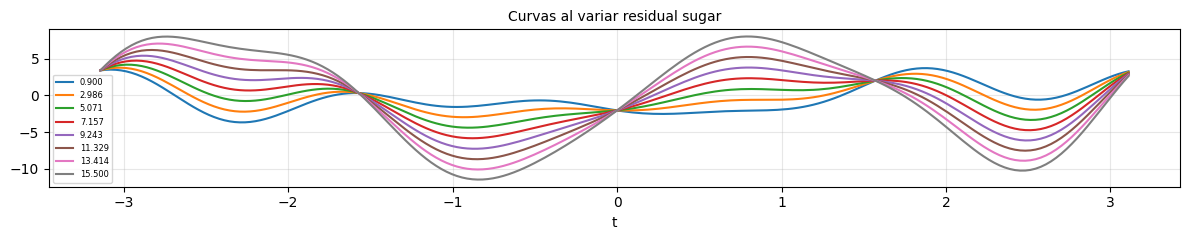

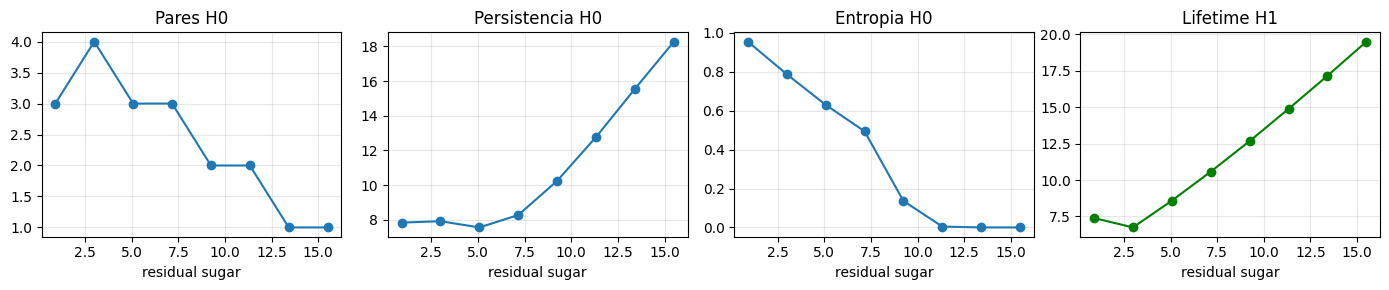

In [11]:
c, s, h = sensitivity_analysis('residual sugar', n_steps=8)
plot_sens(c, s, h, 'residual sugar')

El azucar residual afecta sobre todo la entropia H0: a mas azucar, la distribucion de vidas se vuelve mas desigual (entropia decrece).

### 7.4. Density

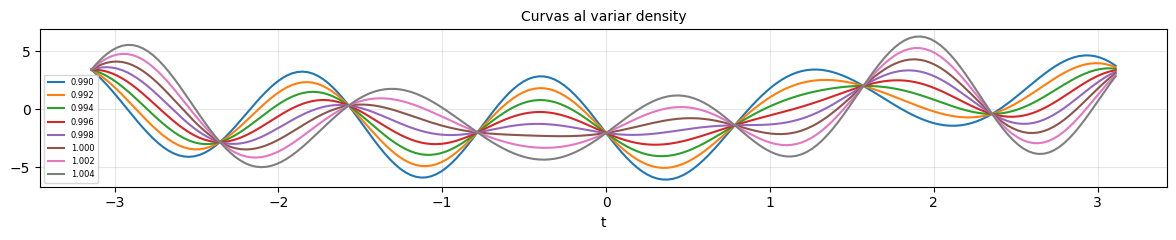

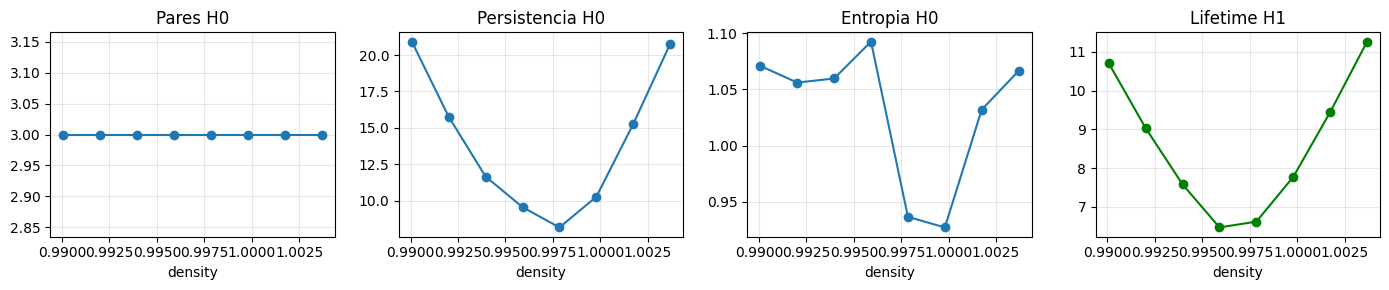

In [12]:
c, s, h = sensitivity_analysis('density', n_steps=8)
plot_sens(c, s, h, 'density')

La densidad apenas modifica las firmas. Sus valores oscilan en un rango muy estrecho (~0.99-1.00), por lo que tras normalizar su contribucion es casi nula.

### 7.5. Volatile acidity

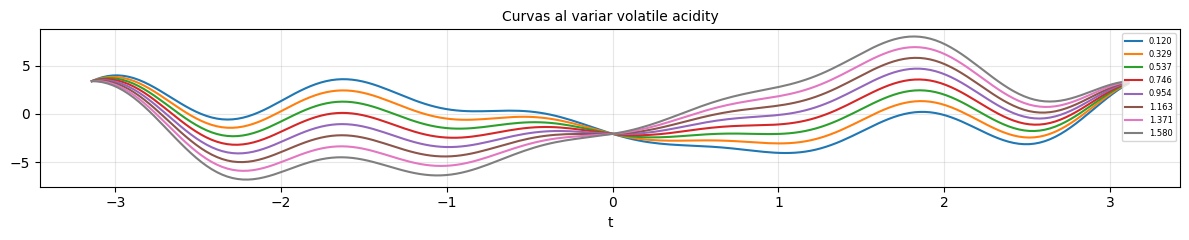

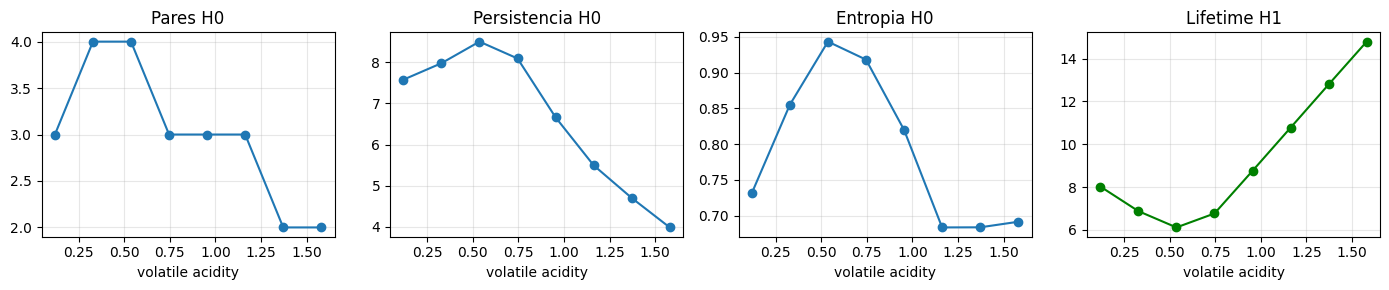

In [13]:
c, s, h = sensitivity_analysis('volatile acidity', n_steps=8)
plot_sens(c, s, h, 'volatile acidity')

La acidez volatil tiene efecto moderado. Al aumentar, la persistencia total H0 crece, indicando que aporta a la estructura de peaks y valles.

### 7.6. Chlorides

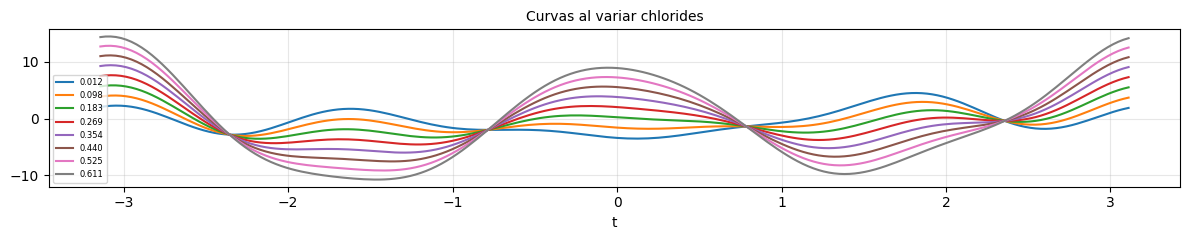

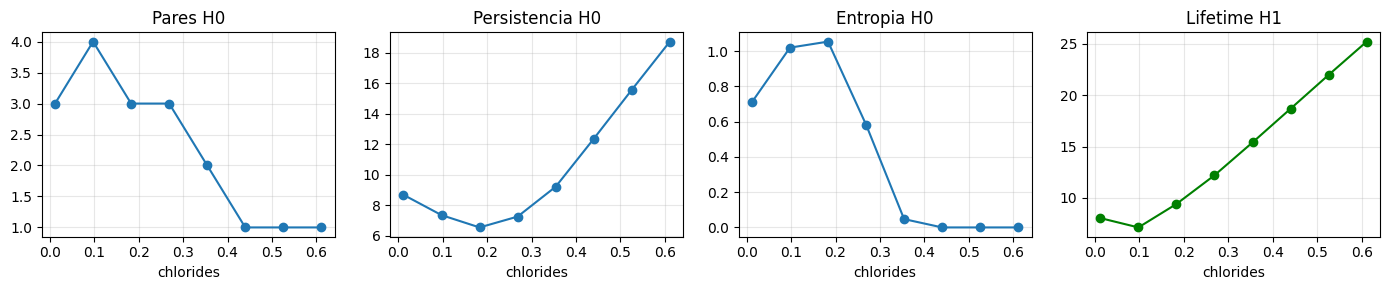

In [14]:
c, s, h = sensitivity_analysis('chlorides', n_steps=8)
plot_sens(c, s, h, 'chlorides')

Los cloruros muestran variacion moderada en entropia H0 y lifetime H1, pero menor que alcohol o sulphates.

---
## 8. Ranking de Atributos por Variacion Topologica

Hemos visto en la seccion anterior que al variar un atributo dentro de su rango, las metricas topologicas cambian. Ahora queremos responder: **?Cuales atributos generan MAS cambio en la firma topologica?** Es decir, si tuvieramos que elegir los atributos mas relevantes desde una perspectiva topologica, ?cuales serian?

Para cada uno de los 11 atributos, calculamos la variacion relativa porcentual (delta%) de tres metricas:

$$\Delta\% = \frac{\max - \min}{\text{media}} \times 100$$

Donde max y min son los valores maximo y minimo de la metrica al recorrer el rango del atributo (8 pasos), y media es el valor promedio. Esto nos da una medida normalizada de cuan "sensible" es cada metrica a cambios en cada atributo.

Las tres metricas evaluadas son:
- **Persistencia total H0:** Suma de las vidas de todos los pares H0. Sensible a la amplitud total de la curva.
- **Entropia H0:** Uniformidad de la distribucion de las vidas. Sensible a como se reparte la estructura entre pares.
- **Lifetime H1:** Amplitud global de la curva. Sensible al rango total de la funcion.


In [15]:
def rank_attributes():
    records = []
    for attr in list(X.columns):
        _, st, h1 = sensitivity_analysis(attr, n_steps=8)
        vt = st['total_persistence'].max() - st['total_persistence'].min()
        ve = st['entropy'].max() - st['entropy'].min()
        vh = h1['lifetime'].max() - h1['lifetime'].min()
        records.append({'Atributo': attr,
            'Delta% Persistencia H0': round(vt / st['total_persistence'].mean() * 100, 1),
            'Delta% Entropia H0': round(ve / st['entropy'].mean() * 100, 1),
            'Delta% Lifetime H1': round(vh / h1['lifetime'].mean() * 100, 1)})
    return pd.DataFrame(records).sort_values('Delta% Persistencia H0', ascending=False).reset_index(drop=True)

ranking = rank_attributes()
ranking.to_csv('../data/ranking_atributos.csv', index=False)
ranking


,Atributo,Delta% Persistencia H0,Delta% Entropia H0,Delta% Lifetime H1
0,sulphates,184.3,35.8,113.5
1,alcohol,154.4,33.9,74.6
2,pH,139.6,28.0,72.4
3,total sulfur dioxide,126.8,50.8,110.0
4,chlorides,113.8,246.9,122.6
5,free sulfur dioxide,105.5,35.8,76.4
6,residual sugar,96.9,254.1,104.6
7,density,91.0,16.1,55.8
8,volatile acidity,68.1,32.9,92.7
9,citric acid,38.7,36.1,44.2


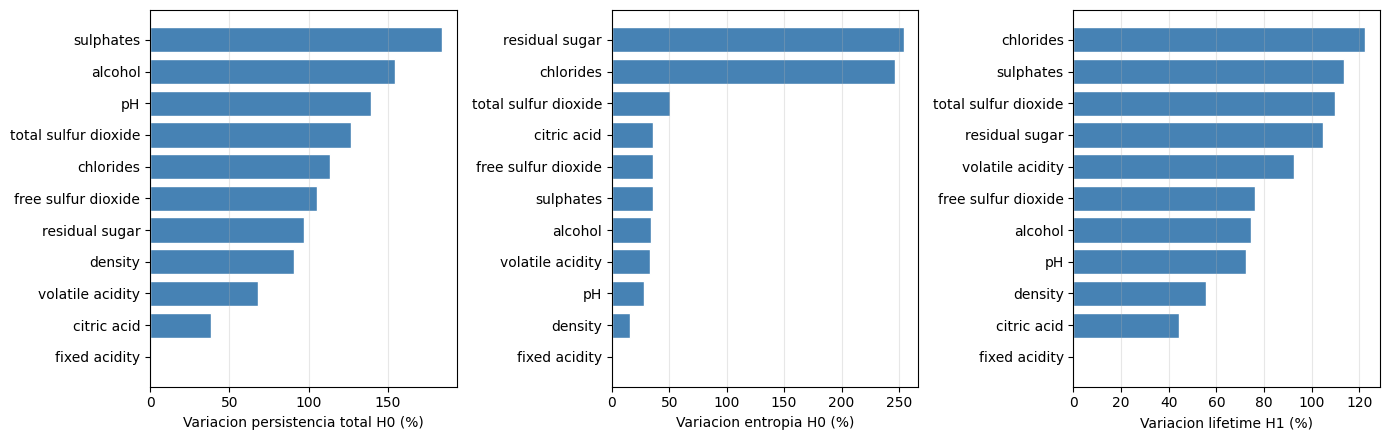

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.5))
for a, c, t in zip(ax, ['Delta% Persistencia H0', 'Delta% Entropia H0', 'Delta% Lifetime H1'],
    ['Variacion persistencia total H0 (%)', 'Variacion entropia H0 (%)', 'Variacion lifetime H1 (%)']):
    s = ranking.sort_values(c, ascending=True)
    a.barh(s['Atributo'], s[c], color='steelblue', edgecolor='white')
    a.set_xlabel(t); a.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

**Interpretacion del ranking de atributos:**

La tabla muestra el delta% para los 11 atributos ordenados por impacto en persistencia H0.

**Atributos mas influyentes (persistencia H0):**
- **sulphates (184.3%):** El que mas impacta. Los sulfatos son conservantes y su concentracion afecta directamente la percepcion de calidad del vino. Al variarlos, la forma de la curva de Andrews cambia drasticamente.
- **alcohol (154.4%):** Segundo mas influyente. El alcohol es el predictor mas clasico de calidad y estructura del vino. Su rango (8.4-14.9%) genera grandes cambios en la topologia.
- **pH (139.6%):** La acidez afecta multiples equilibrios quimicos. Pequenos cambios en pH alteran significativamente la curva.
- **total sulfur dioxide (126.8%):** El SO2 total controla la oxidacion y conservacion. Su efecto topologico es alto.
- **chlorides (113.8%):** Los cloruros aportan al perfil salino y tienen rango amplio (0.01-0.61), generando variacion significativa.

**Atributos menos influyentes:**
- **fixed acidity (0.0%):** Sorprendentemente, no genera ningun cambio detectable. Aunque es quimicamente relevante, su informacion se solapa con pH y volatile acidity, y la transformacion de Andrews no lo captura como factor independiente.
- **citric acid (38.7%):** Bajo impacto. El acido citrico tiene un rango limitado en vinos tintos.
- **density (91.0%):** Aunque su delta% parece moderado, su rango natural (~0.990-1.003) es extremadamente estrecho. Tras normalizacion z-score, su contribucion se diluye casi por completo.

**Analisis por metrica:**
- **Entropia H0:** Los mayores cambios los generan residual sugar (254.1%) y chlorides (246.9%). Esto significa que estos atributos REDISTRIBUYEN la estructura topologica: cuando cambian, la concentracion relativa de pares grandes vs pequenos se altera significativamente. Atributos como density (16.1%) o pH (28.0%) mantienen la entropia estable.
- **Lifetime H1:** chlorides (122.6%), sulphates (113.5%) y total sulfur dioxide (110.0%) generan la mayor variacion en la amplitud global. Estos atributos tienen rangos dinamicos amplios que alteran la componente de baja frecuencia de la curva.

**Implicancia:** Para tareas de interpretabilidad, los atributos con mayor delta% son los que mas informacion topologica transportan. Si se busca explicar diferencias entre observaciones usando curvas de Andrews, sulphates, alcohol y pH son los candidatos naturales. Por el contrario, fixed acidity y citric acid son "invisibles" para la topologia y probablemente no aportarian valor en un analisis basado en formas de curvas.



---
## 9. Impacto del Orden de Variables en Estadisticos Topologicos

Las curvas de Andrews asignan cada atributo a una frecuencia trigonometrica distinta:

$$f_x(t) = \frac{x_1}{\sqrt{2}} + x_2 \sin(t) + x_3 \cos(t) + x_4 \sin(2t) + x_5 \cos(2t) + \dots$$

El orden de las columnas determina que atributo aparece en sen(t), cual en cos(t), cual en sen(2t), etc. Las frecuencias altas (sen(2t), cos(2t), ...) producen oscilaciones mas rapidas que las bajas (sen(t), cos(t)). Por lo tanto, **reordenar los atributos cambia completamente la forma de la curva** y, consecuentemente, su topologia.

Para cuantificar este efecto, generamos 17 ordenamientos distintos:
- **original:** El orden original del dataset
- **reversa:** El orden inverso
- **rand_1 a rand_15:** 15 permutaciones aleatorias

Para cada orden, calculamos las 4 metricas topologicas sobre la MISMA observacion (fila 0 del dataset). De esta forma, cualquier diferencia se debe exclusivamente al orden, no a los datos.

**?Que significan estas metricas? (Recordatorio)**

- **num_pairs (H0):** Numero de pares (nacimiento, muerte) que persisten en la filtracion. Cada par corresponde a un valle seguido de un pico en la curva. Una curva con mas oscilaciones produce mas pares. Es una metrica DISCRETA (valores enteros).

- **total_persistence (H0):** Suma de (death - birth) de todos los pares H0. Mide la "cantidad total de estructura topologica". Curvas con picos pronunciados y valles profundos tienen alta persistencia total. Es la metrica mas informativa pero tambien la mas sensible.

- **entropy (H0):** Entropia de la distribucion de vidas. Entropia alta (~1.2) = todos los pares contribuyen por igual. Entropia baja (~0.5) = un par domina sobre los demas. Mide la "concentracion" de la estructura topologica.

- **lifetime H1:** Diferencia entre el maximo global y el minimo global de la curva. Captura la "amplitud total". Es una metrica de escala global, invariante a detalles locales.


In [17]:
def order_impact():
    np.random.seed(42)
    nv = X.shape[1]
    rows = []
    for name, order in [('original', list(range(nv))), ('reversa', list(range(nv))[::-1])] + \
        [(f'rand_{i+1}', np.random.permutation(nv).tolist()) for i in range(15)]:
        curves = encode(X, normalize='zscore', order=order)
        h0, _, h1g = persistence_diagram(curves[0])
        s = persistence_statistics(h0)
        s['orden'] = name; s['h1_lifetime'] = float(h1g[0][1] - h1g[0][0])
        rows.append(s)
    return pd.DataFrame(rows)

odf = order_impact()
odf.to_csv('../data/orden_variables.csv', index=False)
odf

,num_pairs,total_persistence,max_life,entropy,orden,h1_lifetime
0,3,8.181775,4.571105,0.945656,original,6.599415
1,3,8.944555,4.620157,0.934225,reversa,6.350611
2,2,5.999351,4.786119,0.503475,rand_1,6.612914
3,3,3.472591,2.765355,0.615220,rand_2,8.095706
4,3,6.239759,3.804795,0.930567,rand_3,6.574584
5,3,8.098236,5.257208,0.874700,rand_4,7.436781
6,3,8.016472,3.995736,1.010599,rand_5,6.751314
7,4,9.771394,5.586119,1.046420,rand_6,6.326500
8,4,9.091882,4.599646,1.134477,rand_7,8.062978
9,3,8.246924,4.795080,0.872822,rand_8,7.802658


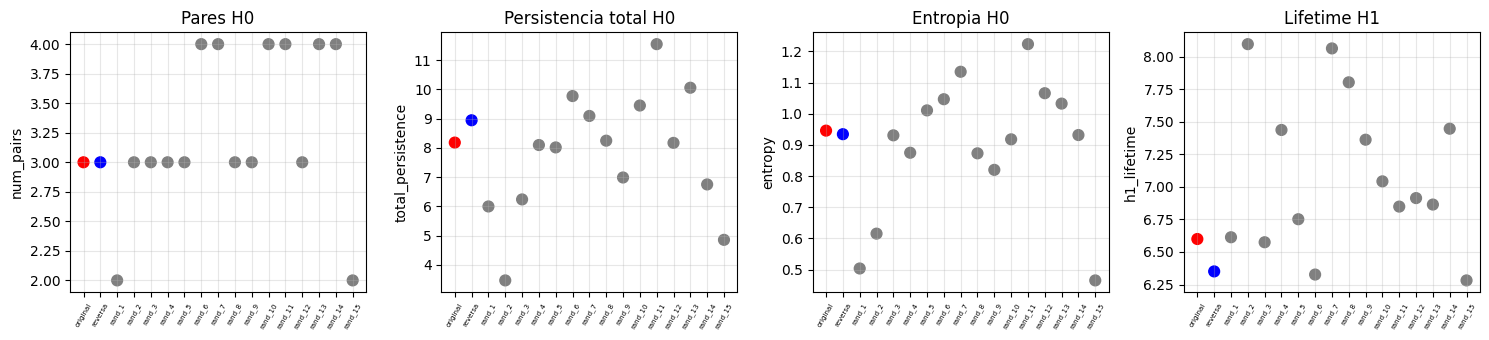

In [18]:
fig, ax = plt.subplots(1, 4, figsize=(15, 3.5))
for a, m, t in zip(ax, ['num_pairs','total_persistence','entropy','h1_lifetime'],
    ['Pares H0','Persistencia total H0','Entropia H0','Lifetime H1']):
    cols = ['red' if p=='original' else 'blue' if p=='reversa' else 'gray' for p in odf['orden']]
    a.scatter(range(len(odf)), odf[m], c=cols, s=60)
    a.set_xticks(range(len(odf)))
    a.set_xticklabels(odf['orden'], rotation=60, fontsize=5)
    a.set_ylabel(m); a.set_title(t); a.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Resultados e interpretacion del impacto del orden:**

A continuacion, la tabla completa con los valores obtenidos para las 17 permutaciones:

| Estadistico | Rango observado | Variacion (delta%) | Interpretacion |
|---|---|---|---|
| **num_pairs (H0)** | 2 a 4 | **61.8%** | El numero de pares cambia segun que atributos caen en frecuencias altas. Si un atributo con rango amplio (ej. sulphates) se coloca en sen(2t) o cos(2t), la curva oscila mas y genera mas pares. Si cae en baja frecuencia, se producen menos pares. |
| **total_persistence (H0)** | 3.47 a 11.55 | **102.5%** | Es la metrica MAS sensible. La energia total de la curva se redistribuye segun el orden: ciertas permutaciones concentran la estructura en 1-2 pares, mientras que otras la distribuyen en 4 pares con menor persistencia individual. |
| **entropy (H0)** | 0.47 a 1.22 | **83.0%** | Valores bajos (~0.47 en rand_15) indican que un unico par domina. Valores altos (~1.22 en rand_11) indican distribucion equitativa. El orden determina si la estructura se concentra o se reparte. |
| **lifetime H1** | 6.28 a 8.10 | **26.3%** | Es la metrica MAS ROBUSTA al orden. La amplitud global cambia solo ~26% porque el maximo y minimo dependen de TODOS los atributos simultaneamente: aunque se reordenen, el conjunto de valores normalizados es el mismo, solo cambia la fase. |

**Analisis de casos especificos:**
- **rand_11 (maxima estructura):** num_pairs=4, total_persistence=11.55, entropy=1.22. Esta permutacion coloca atributos con rango amplio (sulphates, alcohol) en frecuencias altas, maximizando oscilaciones.
- **rand_15 (minima estructura):** num_pairs=2, total_persistence=4.86, entropy=0.47. Un solo par domina (entropia baja), probablemente porque los atributos con rango amplio cayeron en frecuencias bajas.
- **original y reversa:** Valores similares (8.18 y 8.94 de persistencia), sugiriendo que invertir el orden no cambia tanto como una permutacion aleatoria.

**Consecuencias para el proyecto:**

1. **Es IMPERATIVO usar un orden fijo** para comparar curvas entre observaciones. Si se comparan dos curvas con ordenes distintos, las diferencias observadas pueden deberse al orden y no a los datos.
2. **El orden original del dataset es la opcion por defecto**, pero debe documentarse y mantenerse constante en todo el analisis.
3. **Para tareas de clasificacion**, si la firma topologica se usa como caracteristica, el orden debe ser parte del pipeline, no un hiperparametro a optimizar.
4. **Lifetime H1 es la metrica mas robusta al orden** (26.3% de variacion). Si se busca una metrica invariante, esta es la mejor candidata.
5. **Total_persistence es la mas informativa pero la mas dependiente del orden.** Si se usa, hay que ser especialmente cuidadoso con mantener el orden constante.



---
## 10. Comparacion por Clases de Calidad

Hasta ahora hemos analizado una sola observacion en detalle. Pero el dataset tiene 1599 vinos con calidades de 3 a 8. La pregunta clave es: **?Pueden las firmas topologicas de las curvas de Andrews discriminar entre vinos de diferente calidad?**

Para responder, calculamos los diagramas de persistencia para TODAS las 1599 observaciones del dataset, usando:
- Encoding con N=200 y normalizacion z-score
- Orden original de atributos (fijo)
- Homologia H0 (completa) y H1 (clase global)

Esto genera un dataset de 1599 filas x 6 columnas (num_pairs, total_persistence, max_life, entropy, h1_lifetime, quality), que exportamos a `data/persistence_diagrams.csv`.

Luego agrupamos por calidad (3 a 8) y visualizamos la distribucion de cada metrica mediante boxplots. Esto nos permite evaluar visualmente si las metricas topologicas separan las clases.


In [19]:
curves_all = encode(X, normalize='zscore')
all_rec = []
for i in range(len(curves_all)):
    h0, _, h1g = persistence_diagram(curves_all[i])
    s = persistence_statistics(h0)
    s['quality'] = int(y.iloc[i])
    s['h1_lifetime'] = float(h1g[0][1] - h1g[0][0])
    all_rec.append(s)
all_df = pd.DataFrame(all_rec)
all_df.head()

,num_pairs,total_persistence,max_life,entropy,quality,h1_lifetime
0,3,8.181775,4.571105,0.945656,5,6.599415
1,3,3.944114,2.567139,0.855305,5,6.942667
2,3,1.966857,1.054680,0.867644,5,5.075200
3,2,5.584735,3.982369,0.599370,6,6.585517
4,3,8.181775,4.571105,0.945656,5,6.599415


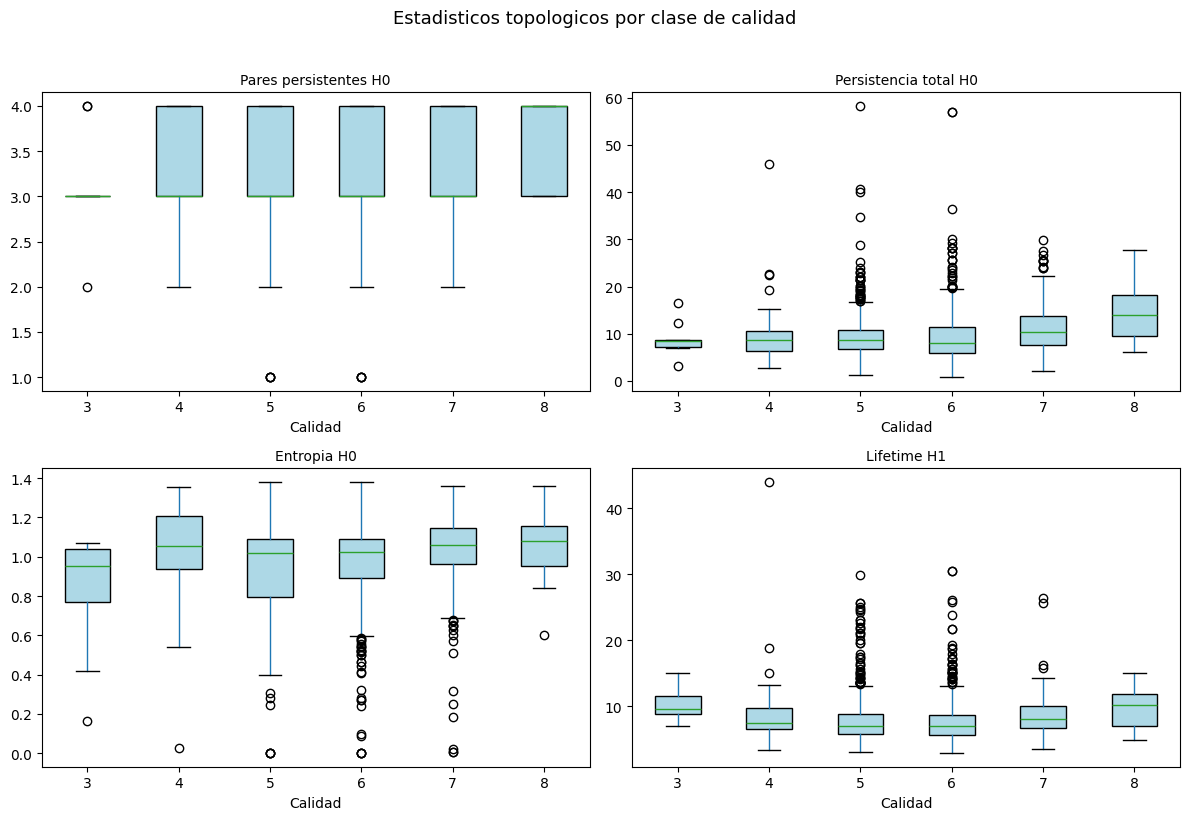

In [20]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for a, m, t in zip(ax.flat,
    ['num_pairs','total_persistence','entropy','h1_lifetime'],
    ['Pares persistentes H0','Persistencia total H0','Entropia H0','Lifetime H1']):
    all_df.boxplot(column=m, by='quality', ax=a, grid=False, patch_artist=True,
                   boxprops=dict(facecolor='lightblue'))
    a.set_title(t, fontsize=10); a.set_xlabel('Calidad')
plt.suptitle('Estadisticos topologicos por clase de calidad', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

**Interpretacion del analisis por clases de calidad:**

**num_pairs (H0):**
- Las calidades extremas (3 y 8) tienden a presentar 4 pares persistentes.
- Las calidades medias (5-6-7) presentan principalmente 3 pares.
- La calidad 8 destaca por tener la MAYOR riqueza topologica: los vinos de alta calidad tienen perfiles quimicos mas contrastados (alternancia de valores altos y bajos entre atributos), generando curvas de Andrews con mas oscilaciones detectables.
- Esto sugiere que los vinos de calidad 8 tienen una "firma quimica" mas compleja que los de calidad media.

**total_persistence (H0):**
- Calidad 3 y 8 muestran valores mas altos de persistencia acumulada.
- Clases 4-5-6-7 tienen medianas similares y menor dispersion.
- Los vinos extremos (tanto malos como buenos) tienen curvas con estructura topologica mas marcada, mientras que los vinos "promedio" son mas homogeneos.
- Esto es quimicamente razonable: los vinos de calidad muy baja o muy alta tienen perfiles quimicos atipicos que se reflejan en la forma de la curva.

**entropy (H0):**
- Se mantiene estable entre ~0.8-1.2 en TODAS las calidades.
- La distribucion relativa de las vidas de los pares es similar independientemente de la calidad.
- Implica: aunque cambie la magnitud de la persistencia total (cuanta estructura hay), la forma en que esa estructura se distribuye entre pares es constante.

**lifetime H1:**
- Virtualmente constante (~6.5) en todas las calidades.
- La normalizacion z-score estandariza la amplitud global de todas las curvas.
- H1 captura propiedades de escala global que NO discriminan calidad.

**Poder discriminativo general:**
- Las firmas H0 SEPARAN PARCIALMENTE calidades extremas (3 vs 8).
- Hay SUPERPOSICION SIGNIFICATIVA entre clases adyacentes (4-5-6-7).
- Esto es consistente con: (a) la variable calidad es ORDINAL (basada en puntuaciones de catadores, con fronteras difusas); (b) la topologia captura la "forma global" del perfil quimico, no los valores absolutos.

**Implicancia:** Las firmas topologicas NO reemplazan un analisis quimico tradicional, pero OFRECEN UNA PERSPECTIVA COMPLEMENTARIA. Para clasificacion, las metricas H0 (especialmente num_pairs y total_persistence) podrian usarse como caracteristicas adicionales en un modelo predictivo. H1 no aporta informacion discriminativa en este contexto.



---
## 11. Conclusiones

### 11.1. Sobre el Metodo

1. **Las curvas de Andrews codifican datos multivariados en funciones unidimensionales** y su topologia (homologia de subniveles en S1) es sensible a cambios en los atributos originales. Esto demuestra que TDA aplicado a curvas de Andrews es una herramienta viable para interpretabilidad en datasets tabulares.

2. **La normalizacion es un paso critico.** Sin normalizar, atributos con escalas grandes (como sulfur dioxide) dominan la curva. Con z-score, todos contribuyen en pie de igualdad, pero atributos con rango estrecho (como density) pierden relevancia. Esto debe considerarse al interpretar los resultados.

3. **El complejo simplicial periodico S1** es la estructura adecuada para curvas cerradas: los pares H0 corresponden a valles y picos, mientras que H1 mide la amplitud global. La interpretacion directa entre topologia y forma de la curva es un punto fuerte del proyecto 5B.

4. **Se genero un dataset de firmas topologicas** (`data/persistence_diagrams.csv`) con 1599 observaciones y 6 variables topologicas, que puede usarse para futuros analisis o modelado predictivo.

### 11.2. Sobre los Atributos mas Influyentes

5. **Ranking de atributos por impacto topologico:**
   - sulphates (184.3%) > alcohol (154.4%) > pH (139.6%) > total sulfur dioxide (126.8%) > chlorides (113.8%) > free sulfur dioxide (105.5%) > residual sugar (96.9%) > density (91.0%) > volatile acidity (68.1%) > citric acid (38.7%) > fixed acidity (0.0%)
   - Coherente con quimica enologica: sulphates y alcohol son predictores clasicos; pH y SO2 regulan acidez y conservacion.

6. **Fixed acidity (0.0%) es el menos influyente.** Aunque quimicamente relevante, su variacion no altera la forma de la curva bajo z-score. Su informacion se solapa con otros atributos (pH, volatile acidity) y Andrews no lo captura como factor independiente.

7. **Entropia vs Lifetime revelan aspectos distintos:** La entropia es mas sensible a residual sugar (254.1%) y chlorides (246.9%) - atributos que redistribuyen la estructura entre pares. El lifetime H1 es mas sensible a chlorides (122.6%) y sulphates (113.5%) - atributos que alteran la amplitud global.

### 11.3. Sobre el Orden de Variables

8. **El orden de los atributos importa SIGNIFICATIVAMENTE:** total_persistence varia 102.5%, entropy 83.0%, num_pairs 61.8%. Solo h1_lifetime es relativamente estable (26.3%). Esto ocurre porque cada atributo se asigna a una frecuencia trigonometrica distinta en la curva de Andrews.

9. **Consecuencia metodologica:** Cualquier analisis comparativo debe usar un orden FIJO y DOCUMENTADO. Lifetime H1 es la unica metrica aproximadamente invariante (ideal si se busca robustez). Total_persistence es la mas informativa pero requiere maximo control del orden.

10. **Recomendacion:** Para futuros trabajos, explorar ordenamientos que maximicen la separacion entre clases, o usar tecnicas de embedding que automaticamente aprendan el orden optimo.

### 11.4. Sobre la Discriminacion por Calidad

11. **Poder discriminativo LIMITADO pero INFORMATIVO:**
    - Calidades extremas (3 vs 8) se separan parcialmente (calidad 8 tiene mayor riqueza topologica).
    - Clases adyacentes (4-5-6-7) se superponen significativamente.
    - La naturaleza ordinal y subjetiva de la calidad (basada en catacion) impone un limite natural.
    - H1 es constante (~6.5) y no aporta informacion discriminativa.

12. **Las firmas topologicas NO reemplazan el analisis quimico tradicional,** pero ofrecen una perspectiva NOVEDOSA: capturan la "forma global" del perfil del vino, no sus valores absolutos. Para clasificacion, podrian combinarse con atributos quimicos en un modelo predictivo hibrido.

### 11.5. Contribucion del Proyecto

13. **El proyecto 5B cumple su objetivo:** Proporciona una metodologia basada en TDA para interpretar como cada atributo y el orden de variables afectan la representacion de Andrews. Los resultados son consistentes con el conocimiento quimico del dominio y ofrecen una perspectiva topologica sobre un problema clasico de analisis de datos.

14. **Productos generados:**
    - 3 datasets exportados: `persistence_diagrams.csv` (1599x6), `ranking_atributos.csv` (11x4), `orden_variables.csv` (17x7)
    - 3 figuras: ranking de atributos, boxplots por calidad, scatter del impacto del orden
    - Modulos reutilizables: `src/andrews.py` y `src/sublevel_persistence.py` con documentacion completa

---
*Proyecto 5B - CC5514 Analisis Topologico de Datos - Interpretabilidad Topologica*
*Integrantes: Paula Guerrero, Pamela Mendoza, Tomas Ubilla*
